# Pipeline d'entraînement MLlib — Scoring produits d'épargne (V1.1)

Consomme la sortie de `EDA_final.ipynb` (`PATH_TRAIN_OUT` / `PATH_SCORER_OUT` — parquet nettoyé,
catégorielles encore brutes). Encode, assemble, entraîne, évalue, sauvegarde, puis score.

**Principe de non-fuite** : tout ce qui est appris (indexeurs, encodeurs, poids de classe, modèle)
est **fit uniquement sur le train**, sauvegardé en `PipelineModel`, puis **rechargé tel quel** pour
scorer `dataset_a_scorer` — même logique que l'`Imputer`/les bornes IQR/les flags dans la Partie 1
EDA.

**Corrections apportées dans cette version (vs. V1) :**
- Ajout du **nettoyage de frontière par Tomek Links** (guide section 7.6bis), en pandas, sur le
  train étiqueté uniquement, **avant** le split train/validation.
- Ajout de la **pondération inverse-fréquence par classe** (guide section 7.6), recalculée
  **après** Tomek Links (la distribution des classes change), injectée via `weightCol` dans le
  classifieur.
- Correction d'une affirmation fausse en section 10 (V1) : `RandomForestClassifier` **supporte**
  `weightCol` depuis Spark 3.0 — le guide (section 7.5) l'utilise explicitement. La V1 prétendait
  le contraire, ce qui n'était pas cohérent avec le guide.
- Le lookup manuel `F.udf(...)` en section scoring remplacé par `IndexToString` (guide section
  7.3), qui est l'outil MLlib documenté pour cette conversion indice → nom de produit.

**Plan :**
1. Imports & configuration
2. Chargement du train nettoyé
3. Nettoyage de frontière (Tomek Links)
4. Split train / validation
5. Pondération inverse-fréquence par classe
6. Construction du pipeline (encodage → assemblage → modèle pondéré)
7. Entraînement
8. Évaluation (accuracy, F1 pondéré, matrice de confusion)
9. Importance des variables
10. Refit sur 100% du train (poids recalculés) & sauvegarde
11. Scoring (`dataset_a_scorer`)
12. Limites de cette V1.1 & prochaines étapes

## 1. Imports & configuration

In [1]:
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, IndexToString
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# pip install imbalanced-learn --break-system-packages (si pas déjà présent dans l'environnement)
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE


In [2]:
# ═══ Bascule LOCAL / MinIO — même principe que la Partie 1 EDA ═══
LOCAL_MODE = False

if LOCAL_MODE:
    # Pour l'instant : le CSV nettoyé exporté par EDA_final.ipynb (Partie 1 -> Partie 2).
    # Une fois le pipeline validé en local, on rebasculera sur le parquet produit par
    # traiter_dataset(is_train=True) puis, à terme, sur le bucket MinIO (branche else ci-dessous).
    PATH_TRAIN_IN = "final_eligibilite.csv"
    PATH_SCORER_IN = None                                    # pas encore testé en local
    PATH_PREDICTIONS_OUT = "new_test/predictions.parquet"
    MODEL_PATH = "./models/scoring_pipeline"
else:
    # CORRECTIF : aligne sur la sortie reelle d'EDA (dataset_eligibilite_final/, pas
    # dataset_train_produits_final/ qui n'existe pas dans ce bucket -- cf. EDA cellule 3).
    PATH_TRAIN_IN = "s3a://processed-data/dataset_eligibilite_final/"
    # Pas encore de dataset a scorer disponible sur MinIO pour l'eligibilite -- laisse a
    # None, la cellule 11 (scoring) gere deja ce cas et l'affiche clairement au lieu de planter.
    PATH_SCORER_IN = None
    PATH_PREDICTIONS_OUT = "s3a://processed-data/predictions/"
    MODEL_PATH = "s3a://ml-scoring/models/scoring_pipeline"

RANDOM_SEED = 42


In [3]:
# CORRECTIF POTENTIEL : ces deux listes DOIVENT rester identiques à celles de la
# Partie 1 EDA (section 0) -- si l'une évolue sans l'autre, le pipeline plante au
# fit (colonne absente) ou encode silencieusement moins de colonnes que prévu.
# TODO V2 : factoriser dans un module partagé (ex. config.py) importé par les deux
# notebooks, plutôt que dupliqué ici.
COLS_CATEGORIELLES_BASSE_CARDINALITE = [
    "GENDER", "TAILLE_ENTREPRI", "pack_actuel", "pack_etat",
    "CUSTOMER_RATING", "MARITAL_STATUS", "BPR",
]
# CORRECTIF : BPR est un code numérique (int64, 12 modalités : 1, 17, 27, 30,
# 43, 45, 50, 57, 64, 78, 81, 90) sans relation d'ordre -- ce n'est PAS une
# quantité. Laissé tel quel, il finissait dans colonnes_features_numeriques()
# (section 6/7) comme feature numérique brute : le modèle apprenait un ordre
# arbitraire entre les codes (78 > 45) qui n'a aucun sens métier. Basse
# cardinalité (12) -> sa place est ici, StringIndexer + OneHotEncoder
# (section 6) plutôt qu'assemblé tel quel comme numérique. Même logique à
# appliquer à toute future colonne "code" numérique à faible cardinalité --
# ne pas se fier au dtype pandas/Spark, se fier au nombre de modalités.
COL_HAUTE_CARDINALITE = "CODE_VILLE"  # indexé seul, jamais one-hot (haute cardinalité -- nb exact calculé dynamiquement section 6, cf. nb_modalites_ville)
COL_LABEL = "label_eligibilite"
COLS_A_EXCLURE_DES_FEATURES = ["label_code", "label_eligibilite"]  # cible, sous ses deux formes


## 2. Spark session & chargement du train nettoyé

In [4]:
def get_spark() -> SparkSession:
    builder = SparkSession.builder.appName("training_pipeline_scoring")
    if LOCAL_MODE:
        # CORRECTIF (OOM) : jamais configuré -> spark.driver.memory par défaut (1g).
        # En local[*], driver et executors partagent la même JVM -- avec maxBins ~863
        # (CODE_VILLE, section 6), TOUTES les features de l'arbre sont binnées sur ce
        # même nombre de bins, pas seulement CODE_VILLE_idx -- les statistiques par
        # noeud explosent, surtout avec CrossValidator (section 9bis) qui fait tourner
        # plusieurs fits en parallèle. 6g est un point de départ raisonnable pour un
        # poste de dev -- ajuster à la baisse/hausse selon la RAM disponible (ne pas
        # dépasser ~70-80% de la RAM physique).
        builder = builder.master("local[*]").config("spark.driver.memory", "6g")
    else:
        builder = (
            builder.master("spark://spark-master:7077")
            .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000")
            .config("spark.hadoop.fs.s3a.access.key", "minioadmin")
            .config("spark.hadoop.fs.s3a.secret.key", "minioadmin123")
            .config("spark.hadoop.fs.s3a.path.style.access", "true")
            .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
        )
    spark = builder.getOrCreate()
    spark.sparkContext.setLogLevel("WARN")
    return spark


def charger_dataset(path: str) -> DataFrame:
    """Charge le dataset nettoyé (sortie de la Partie 1 EDA), en CSV (mode local
    actuel, ex. final.csv) ou en parquet (bucket MinIO, une fois LOCAL_MODE=False).

    Le CSV n'a pas de schéma typé natif -- inferSchema le lirait sans distinction
    entre catégorielle et numérique. Danger particulier : CODE_VILLE (haute
    cardinalité, section 6/COL_HAUTE_CARDINALITE) contient des valeurs comme
    "101", "780" -- inferSchema les lirait comme entier, ce qui casserait le
    StringIndexer prévu pour cette colonne (traitée comme catégorielle, jamais
    comme une quantité). On la recast explicitement en string après lecture.
    """
    if path.endswith(".csv"):
        df = spark.read.csv(path, header=True, inferSchema=True)
        df = df.withColumn(COL_HAUTE_CARDINALITE, F.col(COL_HAUTE_CARDINALITE).cast("string"))
        return df
    return spark.read.parquet(path)


spark = get_spark()
df_train_full = charger_dataset(PATH_TRAIN_IN)
print(f"{df_train_full.count()} lignes, {len(df_train_full.columns)} colonnes")
df_train_full.printSchema()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/17 08:37:34 WARN Utils: Your hostname, Speranz, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/07/17 08:37:35 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/17 08:37:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


95326 lignes, 40 colonnes
root
 |-- CODE_VILLE: string (nullable = true)
 |-- BPR: integer (nullable = true)
 |-- GENDER: string (nullable = true)
 |-- MARITAL_STATUS: string (nullable = true)
 |-- NOMBRE_ENFANT: integer (nullable = true)
 |-- CUSTOMER_RATING: string (nullable = true)
 |-- TAILLE_ENTREPRI: string (nullable = true)
 |-- age_client: integer (nullable = true)
 |-- pack_actuel: string (nullable = true)
 |-- pack_etat: string (nullable = true)
 |-- solde_moyen: double (nullable = true)
 |-- solde_min: double (nullable = true)
 |-- nb_mois_observes_solde: integer (nullable = true)
 |-- depot_moyen: double (nullable = true)
 |-- flux_cred_total: double (nullable = true)
 |-- nb_mois_avec_flux: integer (nullable = true)
 |-- nb_operations_gab: integer (nullable = true)
 |-- montant_total_gab: double (nullable = true)
 |-- montant_moyen_gab: double (nullable = true)
 |-- nb_retraits: integer (nullable = true)
 |-- montant_total_retraits: double (nullable = true)
 |-- nb_paiemen

In [5]:
def colonnes_features_numeriques(df: DataFrame) -> list:
    """Toutes les colonnes numériques du dataset, hors cible et hors colonnes
    catégorielles couvertes par l'encodage (section 6) -- sinon on se retrouverait
    avec CODE_VILLE brut ET CODE_VILLE_idx dans le vecteur final. Utilisée à la
    fois pour Tomek Links (section 3, sur les features numériques uniquement --
    TomekLinks calcule des distances, incompatible avec des catégorielles brutes
    non encodées à ce stade) et pour VectorAssembler (section 6)."""
    cols_categorielles_brutes = set(COLS_CATEGORIELLES_BASSE_CARDINALITE + [COL_HAUTE_CARDINALITE])
    return [
        c for c, t in df.dtypes
        if t in ("int", "bigint", "double", "float")
        and c not in COLS_A_EXCLURE_DES_FEATURES
        and c not in cols_categorielles_brutes
    ]


feature_cols_numeriques = colonnes_features_numeriques(df_train_full)
print(f"Features numériques ({len(feature_cols_numeriques)}) : {feature_cols_numeriques}")


Features numériques (31) : ['NOMBRE_ENFANT', 'age_client', 'solde_moyen', 'solde_min', 'nb_mois_observes_solde', 'depot_moyen', 'flux_cred_total', 'nb_mois_avec_flux', 'nb_operations_gab', 'montant_total_gab', 'montant_moyen_gab', 'nb_retraits', 'montant_total_retraits', 'nb_paiements_digitaux', 'montant_total_payfac', 'nb_vignettes_payees', 'montant_total_vignette', 'jamais_active_digital', 'jamais_utilise_gab', 'anciennete_digitale_jours_imp', 'recence_gab_jours_imp', 'nb_mois_observes_solde_etait_extreme', 'solde_moyen_etait_extreme', 'solde_min_etait_extreme', 'solde_max_etait_extreme', 'depot_moyen_etait_extreme', 'flux_cred_moyen_etait_extreme', 'flux_cred_total_etait_extreme', 'montant_total_retraits_etait_extreme', 'solde_volatilite_indefinie', 'solde_volatilite_relative_imp']


## 3. Nettoyage de frontière (Tomek Links)

Guide, section 7.6bis. Un lien de Tomek est une paire de points de classes différentes qui sont
chacun le plus proche voisin de l'autre — un signal de frontière, voire d'empiètement de la
classe majoritaire sur la zone d'une classe minoritaire. Les supprimer nettoie la frontière de
décision. **Complémentaire à la pondération de classe (section 5), pas un substitut** : Tomek
Links agit sur les *lignes* avant l'entraînement, la pondération agit sur la *fonction de coût*
pendant l'entraînement.

**Pourquoi en pandas et pas en Spark** : `imbalanced-learn` n'a pas d'équivalent distribué
natif dans MLlib. Ce n'est pas un problème ici : Tomek Links ne s'applique **qu'au train
étiqueté** (ce fichier), jamais à `dataset_a_scorer` (potentiellement 3M+ lignes une fois sur
MinIO) — un aller-retour pandas sur un fichier de cette taille est sans risque mémoire.

**Ordre à respecter** (guide) : Tomek Links tourne **avant** le split train/validation (section 4)
et **avant** le calcul des poids de classe (section 5, qui doit refléter la distribution
post-Tomek, pas la distribution brute).

In [6]:
RADICAL_PRESENT = "RADICAL" in df_train_full.columns

# CORRECTIF : on sélectionne désormais TOUTES les colonnes de df_train_full (pas
# seulement RADICAL + numériques + label). L'ancienne version, quand RADICAL était
# absent (cas de final.csv, colonnes techniques déjà supprimées en amont), retombait
# sur train_pd_clean qui ne contenait QUE les numériques + le label -- les
# catégorielles brutes (GENDER, MARITAL_STATUS, ...) disparaissaient de
# df_train_full et l'encodage (section 6) plantait plus loin avec "Input column
# GENDER does not exist". En gardant toutes les colonnes ici, indices_conserves
# (calculé sur les seules features numériques, cf. plus bas) reste valide pour
# indexer train_pd puisque son index pandas n'a pas changé -- et le rejoin
# RADICAL devient inutile, qu'il soit présent ou non.
cols_tomek = df_train_full.columns

train_pd = df_train_full.select(*cols_tomek).toPandas()
print(f"Avant Tomek Links : {len(train_pd)} lignes")
print(train_pd[COL_LABEL].value_counts())

X = train_pd[feature_cols_numeriques]
y = train_pd[COL_LABEL]

tomek = TomekLinks(sampling_strategy="auto")
X_res, y_res = tomek.fit_resample(X, y)

# fit_resample renvoie de nouveaux index -- on les utilise pour retrouver les
# lignes conservées, avec TOUTES les colonnes d'origine (cf. correctif ci-dessus),
# pas seulement les features numériques utilisées pour le calcul des distances.
indices_conserves = X_res.index
train_pd_clean = train_pd.loc[indices_conserves].reset_index(drop=True)

print(f"Après Tomek Links : {len(train_pd_clean)} lignes "
      f"({len(train_pd) - len(train_pd_clean)} supprimée(s), frontière entre classes)")
print(train_pd_clean[COL_LABEL].value_counts())

# Retour dans Spark : train_pd_clean porte déjà toutes les colonnes, plus besoin
# de rejoindre sur RADICAL pour les récupérer.
df_train_full = spark.createDataFrame(train_pd_clean)

df_train_full.cache()
print(f"\ndf_train_full après Tomek Links : {df_train_full.count()} lignes")


26/07/17 08:38:54 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Avant Tomek Links : 95326 lignes
label_eligibilite
0    91321
1     4005
Name: count, dtype: int64
Après Tomek Links : 93460 lignes (1866 supprimée(s), frontière entre classes)
label_eligibilite
0    89553
1     3907
Name: count, dtype: int64


26/07/17 08:42:31 WARN TaskSetManager: Stage 6 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:42:46 WARN TaskSetManager: Stage 7 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.



df_train_full après Tomek Links : 93460 lignes


## 4. Split train / validation

Un split est fait ici **en plus** du train/scoring déjà séparé en amont (Partie 1 EDA) : celui-là
sépare "données qu'on a le droit d'utiliser" de "données de production", celui-ci sépare "données
pour entraîner" de "données pour évaluer honnêtement avant de livrer le modèle". Sans ce split, la
métrique d'évaluation serait mesurée sur les données mêmes qui ont servi à fitter les indexeurs et
le classifieur -- optimiste, pas fiable.

Split fait **après** Tomek Links (section 3), sur `df_train_full` déjà nettoyé -- le `PipelineModel`
final (section 10) sera de toute façon refit sur 100% de ce `df_train_full` nettoyé une fois la
V1.1 validée ici.

In [7]:
df_fit, df_val = df_train_full.randomSplit([0.8, 0.2], seed=RANDOM_SEED)
df_fit.cache()
df_val.cache()
print(f"Fit  : {df_fit.count()} lignes")
print(f"Val  : {df_val.count()} lignes")

print("\nÉquilibre des classes -- fit vs val (doivent être comparables) :")
df_fit.groupBy(COL_LABEL).count().withColumn("part_fit", F.round(F.col("count") / df_fit.count(), 3)).show()
df_val.groupBy(COL_LABEL).count().withColumn("part_val", F.round(F.col("count") / df_val.count(), 3)).show()


26/07/17 08:42:49 WARN TaskSetManager: Stage 10 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:42:56 WARN TaskSetManager: Stage 11 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.


Fit  : 74974 lignes


26/07/17 08:42:57 WARN TaskSetManager: Stage 14 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:42:59 WARN TaskSetManager: Stage 15 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.


Val  : 18486 lignes

Équilibre des classes -- fit vs val (doivent être comparables) :


26/07/17 08:43:01 WARN TaskSetManager: Stage 18 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:43:02 WARN TaskSetManager: Stage 21 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.


+-----------------+-----+--------+
|label_eligibilite|count|part_fit|
+-----------------+-----+--------+
|                0|71848|   0.958|
|                1| 3126|   0.042|
+-----------------+-----+--------+



26/07/17 08:43:05 WARN TaskSetManager: Stage 24 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:43:06 WARN TaskSetManager: Stage 27 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.


+-----------------+-----+--------+
|label_eligibilite|count|part_val|
+-----------------+-----+--------+
|                0|17705|   0.958|
|                1|  781|   0.042|
+-----------------+-----+--------+



## 5. Pondération inverse-fréquence par classe

Guide, section 7.6. Complémentaire à Tomek Links (section 3) : Tomek nettoie les lignes
ambiguës à la frontière, la pondération force le classifieur à ne pas ignorer les classes rares
pendant l'apprentissage. **Calculée après Tomek Links**, sur `df_fit` -- la distribution des
classes a changé suite au nettoyage de frontière, un poids calculé sur la distribution brute
d'avant-Tomek serait faux.

Formule (guide) : `poids_classe = total / (nb_classes × effectif_de_la_classe)` -- pondération
inverse-fréquence standard multi-classe, chaque classe rare reçoit un poids proportionnellement
plus élevé.

In [8]:
def calculer_poids_classe(df: DataFrame, col_label: str = COL_LABEL) -> DataFrame:
    """Retourne un DataFrame [col_label, poids_classe] à joindre sur le train
    (fit ou full) juste avant l'entraînement. Recalculé à chaque fois que la
    population d'entrée change (ex. fit vs. full au refit de la section 10)."""
    effectifs = df.groupBy(col_label).count()
    total = df.count()
    nb_classes = effectifs.count()

    # CORRECTIF (precision effondree) : la formule inverse-frequence brute (poids ~ 1/effectif)
    # sur-corrige un desequilibre ~96/4 -- le classifieur finit par predire la classe 1 en
    # exces (rappel eleve, precision ~0.08 observe). Racine carree : compromis plus doux,
    # la classe rare reste sur-ponderee mais moins agressivement.
    poids = effectifs.withColumn(
        "poids_classe", F.sqrt(total / (nb_classes * F.col("count")))
    ).select(col_label, "poids_classe")

    print(f"\nPoids par classe (total={total}, nb_classes={nb_classes}) :")
    poids.orderBy(col_label).show()
    return poids


poids_par_classe_fit = calculer_poids_classe(df_fit)
df_fit = df_fit.join(poids_par_classe_fit, on=COL_LABEL)


26/07/17 08:43:07 WARN TaskSetManager: Stage 30 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:43:08 WARN TaskSetManager: Stage 33 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.



Poids par classe (total=74974, nb_classes=2) :


26/07/17 08:43:11 WARN TaskSetManager: Stage 39 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.


+-----------------+------------------+
|label_eligibilite|      poids_classe|
+-----------------+------------------+
|                0|0.5217542589912036|
|                1|11.992002559181062|
+-----------------+------------------+



## 6. Construction du pipeline

Trois familles de stages, dans l'ordre où Spark doit les exécuter :

1. **Encodage catégoriel** : `StringIndexer` + `OneHotEncoder` pour les colonnes basse-cardinalité,
   `StringIndexer` seul pour `CODE_VILLE` (haute cardinalité — un `OneHotEncoder` dessus
   exploserait le nombre de features pour un gain incertain).
2. **Indexation de la cible** : `label_nom` (string) → `label_idx` (double), requis par les
   classifieurs MLlib.
3. **Assemblage** : toutes les features numériques + toutes les sorties d'encodage dans un seul
   vecteur `features`, puis le classifieur, **pondéré par `poids_classe`** (section 5).

`RandomForestClassifier` choisi pour cette V1.1 : robuste aux features non standardisées, gère
nativement `CODE_VILLE_idx` à haute cardinalité sans que l'ordre numérique arbitraire de l'index
ne biaise le modèle (contrairement à une régression logistique), **et supporte `weightCol`
nativement depuis Spark 3.0** — exactement l'exemple du guide (section 7.5).

In [9]:
def construire_stages_encodage(cols_basse_cardinalite: list, col_haute_cardinalite: str):
    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in cols_basse_cardinalite
    ]
    encoders = [
        OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
        for c in cols_basse_cardinalite
    ]
    indexer_haute_card = StringIndexer(
        inputCol=col_haute_cardinalite, outputCol=f"{col_haute_cardinalite}_idx", handleInvalid="keep"
    )
    return indexers + encoders + [indexer_haute_card]


encodage_stages = construire_stages_encodage(COLS_CATEGORIELLES_BASSE_CARDINALITE, COL_HAUTE_CARDINALITE)

label_indexer = StringIndexer(inputCol=COL_LABEL, outputCol="label_idx", handleInvalid="error")

feature_cols_encodees = [f"{c}_ohe" for c in COLS_CATEGORIELLES_BASSE_CARDINALITE] + [f"{COL_HAUTE_CARDINALITE}_idx"]
feature_cols = feature_cols_numeriques + feature_cols_encodees

print(f"Features numériques ({len(feature_cols_numeriques)}) : {feature_cols_numeriques}")
print(f"Features encodées   ({len(feature_cols_encodees)}) : {feature_cols_encodees}")

# handleInvalid="skip" : "poids_classe" n'est PAS dans inputCols, VectorAssembler
# ne le touche pas -- il reste disponible comme colonne à part pour weightCol ci-dessous.
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

# CORRECTIF : RandomForestClassifier traite CODE_VILLE_idx comme une feature
# catégorielle (métadonnée posée par le StringIndexer) et exige maxBins >= son
# nombre de modalités -- sinon Spark lève IllegalArgumentException au .fit().
# maxBins par défaut (32) est très inférieur aux ~273 modalités de CODE_VILLE
# (guide / COL_HAUTE_CARDINALITE) : on le dimensionne dynamiquement plutôt que
# de fixer une valeur en dur qui casserait si la cardinalité évolue.
nb_modalites_ville = df_train_full.select(COL_HAUTE_CARDINALITE).distinct().count()
max_bins = max(32, nb_modalites_ville + 1)  # +1 : marge pour la modalité "inconnue" (handleInvalid="keep")
print(f"CODE_VILLE : {nb_modalites_ville} modalités observées -> maxBins={max_bins}")

# CORRECTIF (bug bloquant) : max_bins est calculé dynamiquement juste au-dessus
# (>= nb de modalités de CODE_VILLE, ici ~863) mais le classifieur utilisait
# "maxBins=64" en dur -- très inférieur à ~863, ce qui fait planter .fit() avec
# IllegalArgumentException, exactement l'erreur que le commentaire au-dessus
# prétend éviter. La section 9bis (benchmark) utilisait déjà correctement
# "maxBins=max_bins" -- on aligne ici sur la même variable.
clf = RandomForestClassifier(
    labelCol="label_idx",
    featuresCol="features",
    weightCol="poids_classe",
    numTrees=30,
    maxDepth=5,
    maxBins=max_bins,
    seed=RANDOM_SEED,
)

pipeline = Pipeline(stages=encodage_stages + [label_indexer, assembler, clf])


Features numériques (31) : ['NOMBRE_ENFANT', 'age_client', 'solde_moyen', 'solde_min', 'nb_mois_observes_solde', 'depot_moyen', 'flux_cred_total', 'nb_mois_avec_flux', 'nb_operations_gab', 'montant_total_gab', 'montant_moyen_gab', 'nb_retraits', 'montant_total_retraits', 'nb_paiements_digitaux', 'montant_total_payfac', 'nb_vignettes_payees', 'montant_total_vignette', 'jamais_active_digital', 'jamais_utilise_gab', 'anciennete_digitale_jours_imp', 'recence_gab_jours_imp', 'nb_mois_observes_solde_etait_extreme', 'solde_moyen_etait_extreme', 'solde_min_etait_extreme', 'solde_max_etait_extreme', 'depot_moyen_etait_extreme', 'flux_cred_moyen_etait_extreme', 'flux_cred_total_etait_extreme', 'montant_total_retraits_etait_extreme', 'solde_volatilite_indefinie', 'solde_volatilite_relative_imp']
Features encodées   (8) : ['GENDER_ohe', 'TAILLE_ENTREPRI_ohe', 'pack_actuel_ohe', 'pack_etat_ohe', 'CUSTOMER_RATING_ohe', 'MARITAL_STATUS_ohe', 'BPR_ohe', 'CODE_VILLE_idx']


26/07/17 08:43:15 WARN TaskSetManager: Stage 42 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.


CODE_VILLE : 855 modalités observées -> maxBins=856


## 6bis. Aperçu des données encodées

Avant l'entraînement, on vérifie concrètement ce que produisent les `StringIndexer`/`OneHotEncoder`
de la section 6 sur quelques colonnes catégorielles, et à quoi ressemble le vecteur `features` final
assemblé par le `VectorAssembler`. Utile pour repérer une colonne mal encodée avant de lancer un
`.fit()` qui prend du temps sur le vrai classifieur.

In [10]:
# Pipeline "encodage seul" (mêmes stages que la section 6, sans classifieur) -- permet
# de visualiser brut -> index -> one-hot -> vecteur "features" assemblé, sans attendre
# l'entraînement d'un modèle complet.
pipeline_encodage_apercu = Pipeline(stages=encodage_stages + [label_indexer, assembler])
apercu_model = pipeline_encodage_apercu.fit(df_fit)
df_encode_apercu = apercu_model.transform(df_fit)

# 3 colonnes basse-cardinalité suffisent pour illustrer brut -> idx -> ohe, plus CODE_VILLE
# (haute cardinalité, indexé seul) et le vecteur assemblé final.
cols_a_montrer = []
for c in COLS_CATEGORIELLES_BASSE_CARDINALITE[:3]:
    cols_a_montrer += [c, f"{c}_idx", f"{c}_ohe"]
cols_a_montrer += [COL_HAUTE_CARDINALITE, f"{COL_HAUTE_CARDINALITE}_idx", COL_LABEL, "label_idx", "features"]

print("Exemple de lignes encodées :")
df_encode_apercu.select(*cols_a_montrer).show(5, truncate=60)

# Une seule ligne en pandas, vecteur "features" déplié en array pour le lire en clair
exemple_pd = df_encode_apercu.select(*cols_a_montrer).limit(1).toPandas()
exemple_pd["features"] = exemple_pd["features"].apply(lambda v: v.toArray())
exemple_pd.T.rename(columns={0: "valeur_exemple"})

26/07/17 08:43:23 WARN TaskSetManager: Stage 48 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:43:26 WARN TaskSetManager: Stage 51 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:43:31 WARN TaskSetManager: Stage 57 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:43:32 WARN TaskSetManager: Stage 60 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:43:35 WARN TaskSetManager: Stage 66 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:43:36 WARN TaskSetManager: Stage 69 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:43:39 WARN TaskSetManager: Stage 75 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/

Exemple de lignes encodées :


26/07/17 08:44:07 WARN TaskSetManager: Stage 129 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:44:10 WARN TaskSetManager: Stage 132 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.


+------+----------+-------------+---------------+-------------------+-------------------+-----------+---------------+---------------+----------+--------------+-----------------+---------+------------------------------------------------------------+
|GENDER|GENDER_idx|   GENDER_ohe|TAILLE_ENTREPRI|TAILLE_ENTREPRI_idx|TAILLE_ENTREPRI_ohe|pack_actuel|pack_actuel_idx|pack_actuel_ohe|CODE_VILLE|CODE_VILLE_idx|label_eligibilite|label_idx|                                                    features|
+------+----------+-------------+---------------+-------------------+-------------------+-----------+---------------+---------------+----------+--------------+-----------------+---------+------------------------------------------------------------+
|     M|       0.0|(2,[0],[1.0])|    PARTICULIER|                0.0|      (2,[0],[1.0])|  SANS_PACK|            0.0| (77,[0],[1.0])|         0|         291.0|                0|      0.0|(152,[0,1,2,3,4,5,6,7,17,18,19,20,30,31,33,35,113,116,133...|
|   

26/07/17 08:44:13 WARN TaskSetManager: Stage 133 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:44:16 WARN TaskSetManager: Stage 136 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.


,valeur_exemple
GENDER,M
GENDER_idx,0.0
GENDER_ohe,"(1.0, 0.0)"
TAILLE_ENTREPRI,PARTICULIER
TAILLE_ENTREPRI_idx,0.0
TAILLE_ENTREPRI_ohe,"(1.0, 0.0)"
pack_actuel,SANS_PACK
pack_actuel_idx,0.0
pack_actuel_ohe,"(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
CODE_VILLE,0


## 7. Entraînement

Un seul `.fit()` déclenche, dans l'ordre, le fit de chaque `StringIndexer`/`OneHotEncoder` (appris
sur `df_fit` uniquement) puis l'entraînement du `RandomForestClassifier`, pondéré par
`poids_classe`.

In [11]:
pipeline_model = pipeline.fit(df_fit)
print("Entraînement terminé.")


26/07/17 08:44:19 WARN TaskSetManager: Stage 137 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:44:20 WARN TaskSetManager: Stage 140 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:44:22 WARN TaskSetManager: Stage 146 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:44:23 WARN TaskSetManager: Stage 149 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:44:25 WARN TaskSetManager: Stage 155 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:44:26 WARN TaskSetManager: Stage 158 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:44:28 WARN TaskSetManager: Stage 164 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.

Entraînement terminé.


## 8. Évaluation sur le set de validation

Accuracy seule est trompeuse ici (cible déséquilibrée, cf. EDA Partie 2 section 3) — F1 pondéré et
la matrice de confusion donnent une image plus honnête, en particulier sur les classes
minoritaires. `df_val` n'a **pas** de colonne `poids_classe` (jointe uniquement sur `df_fit` en
section 5) — c'est volontaire, l'évaluation doit rester sur la distribution réelle, pas pondérée.

In [12]:
predictions_val = pipeline_model.transform(df_val)

evaluator_acc = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="weightedRecall")
# F1 de la seule classe 1 (minoritaire, ~4.6% du train) -- le F1 pondéré ci-dessus reste
# trompeur pour juger un modèle "paresseux" (cf. section 9quater).
evaluator_f1_classe1 = MulticlassClassificationEvaluator(labelCol="label_idx", predictionCol="prediction", metricName="fMeasureByLabel", metricLabel=1.0)

print(f"Accuracy           : {evaluator_acc.evaluate(predictions_val):.4f}")
print(f"F1 pondéré         : {evaluator_f1.evaluate(predictions_val):.4f}")
print(f"Précision pondérée : {evaluator_precision.evaluate(predictions_val):.4f}")
print(f"Rappel pondéré     : {evaluator_recall.evaluate(predictions_val):.4f}")
print(f"F1 classe 1        : {evaluator_f1_classe1.evaluate(predictions_val):.4f}")


26/07/17 08:45:58 WARN TaskSetManager: Stage 244 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.


Accuracy           : 0.7268


26/07/17 08:46:05 WARN TaskSetManager: Stage 246 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.


F1 pondéré         : 0.8082


26/07/17 08:46:09 WARN TaskSetManager: Stage 248 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.


Précision pondérée : 0.9377


26/07/17 08:46:13 WARN TaskSetManager: Stage 250 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.


Rappel pondéré     : 0.7268


26/07/17 08:46:17 WARN TaskSetManager: Stage 252 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.


F1 classe 1        : 0.1515


Correspondance label_idx -> label_nom : {0: '0', 1: '1'}


26/07/17 08:46:23 WARN TaskSetManager: Stage 254 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.



Matrice de confusion (lignes = réel, colonnes = prédit) :
label_nom_predit      0     1    All
label_nom_reel                      
0                 12984  4721  17705
1                   330   451    781
All               13314  5172  18486


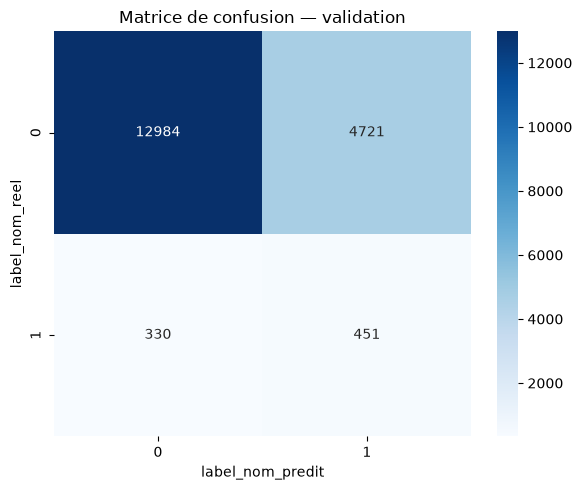

In [13]:
# Matrice de confusion (le set de validation est petit -- OK de collecter en pandas ;
# sur un dataset_a_scorer complet de plusieurs millions de lignes, échantillonner d'abord)
label_map = dict(enumerate(pipeline_model.stages[len(encodage_stages)].labels))  # label_idx -> label_nom
print("Correspondance label_idx -> label_nom :", label_map)

pred_pd = predictions_val.select("label_idx", "prediction").toPandas()
pred_pd["label_nom_reel"] = pred_pd["label_idx"].map(label_map)
pred_pd["label_nom_predit"] = pred_pd["prediction"].map(label_map)

confusion = pd.crosstab(pred_pd["label_nom_reel"], pred_pd["label_nom_predit"], margins=True)
print("\nMatrice de confusion (lignes = réel, colonnes = prédit) :")
print(confusion)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pd.crosstab(pred_pd["label_nom_reel"], pred_pd["label_nom_predit"]), annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Matrice de confusion — validation")
plt.tight_layout()
plt.show()


## 9. Importance des variables

Utile pour vérifier que le modèle s'appuie sur des signaux plausibles (pas uniquement
`CODE_VILLE_idx` ou un artefact du feature engineering) avant de livrer la V1.1.

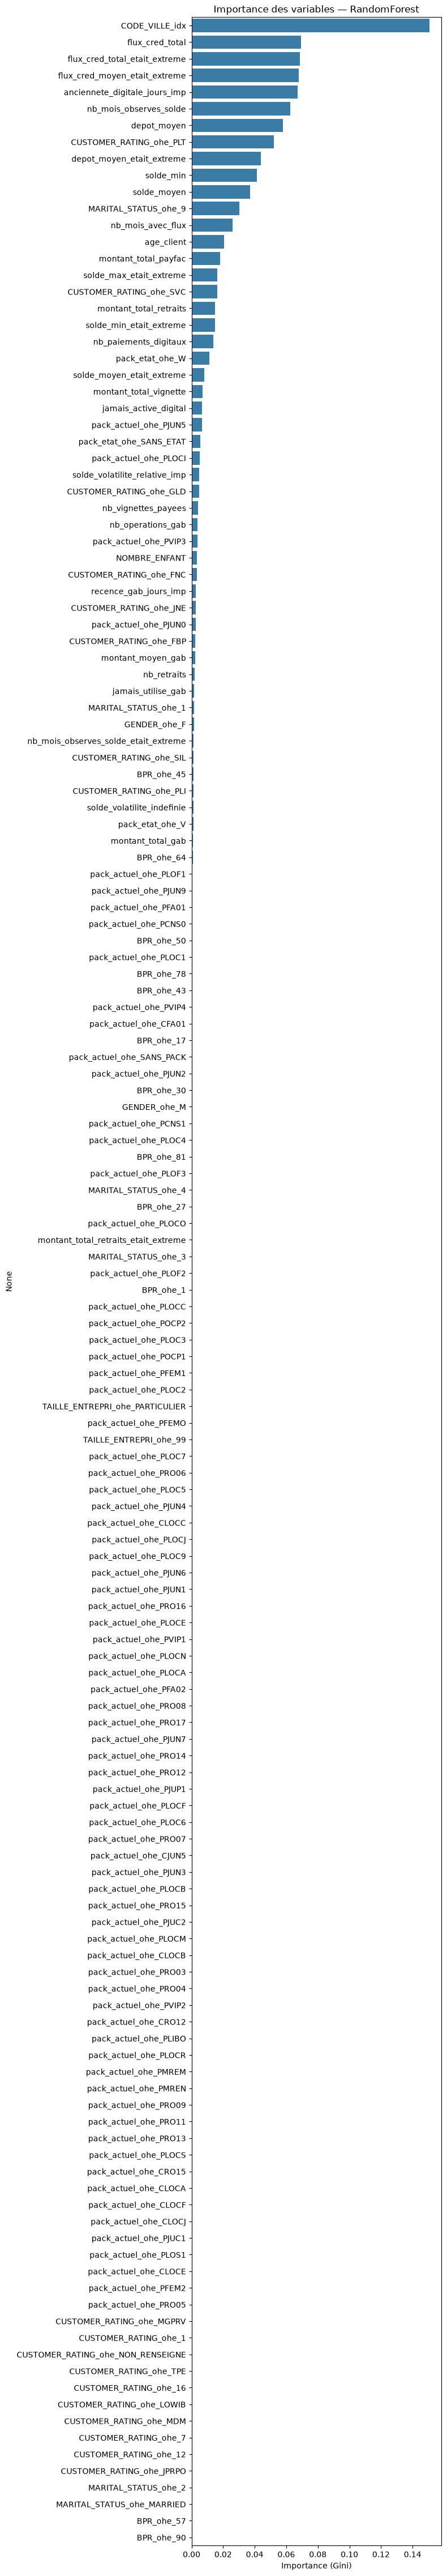

,importance
CODE_VILLE_idx,0.150668
flux_cred_total,0.069180
flux_cred_total_etait_extreme,0.068685
flux_cred_moyen_etait_extreme,0.067959
anciennete_digitale_jours_imp,0.067015
...,...
CUSTOMER_RATING_ohe_JPRPO,0.000000
MARITAL_STATUS_ohe_2,0.000000
MARITAL_STATUS_ohe_MARRIED,0.000000
BPR_ohe_57,0.000000


In [14]:
rf_model = pipeline_model.stages[-1]  # dernier stage du pipeline = le RandomForestClassifier

# CORRECTIF : feature_cols compte une entrée par colonne catégorielle d'origine
# (ex. "GENDER_ohe"), mais OneHotEncoder éclate chacune en plusieurs colonnes
# binaires dans le vecteur "features" assemblé -- la taille ne correspond plus
# (ValueError: Length of values (114) does not match length of index (39)).
# On récupère donc les vrais noms depuis les métadonnées ML posées par le
# VectorAssembler plutôt que de les recompter à la main.
def extraire_noms_features(df, col: str = "features") -> list:
    attrs = df.schema[col].metadata["ml_attr"]["attrs"]
    noms = [None] * sum(len(v) for v in attrs.values())
    for liste_attrs in attrs.values():
        for a in liste_attrs:
            noms[a["idx"]] = a["name"]
    return noms


feature_names_reels = extraire_noms_features(predictions_val)
importances = pd.Series(rf_model.featureImportances.toArray(), index=feature_names_reels)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(importances))))
sns.barplot(x=importances.values, y=importances.index, ax=ax, color="#2980b9")
ax.set_xlabel("Importance (Gini)")
ax.set_title("Importance des variables — RandomForest")
plt.tight_layout()
plt.show()

importances.to_frame("importance")


## 9bis. Benchmark multi-algorithmes avec recherche d'hyperparamètres

Objectif : comparer plusieurs familles d'algorithmes MLlib sur le même split `df_fit` / `df_val`
et les mêmes stages d'encodage (section 6), chacun avec sa propre grille d'hyperparamètres
recherchée par validation croisée (`CrossValidator`, 3 folds), puis les classer sur `df_val`.

**Métrique de sélection** : `fMeasureByLabel` sur la classe 1 (minoritaire, ~4.6% du train),
pas le F1 pondéré -- un modèle qui prédit presque toujours la classe 0 obtient déjà un F1
pondéré élevé sans détecter les clients éligibles, ce qui est précisément ce qu'on veut éviter.

**Algorithmes retenus** — tous supportent nativement le multiclasse (3 classes ici) et `weightCol`,
pour réutiliser la pondération inverse-fréquence de la section 5 :
- `RandomForestClassifier` (déjà utilisé section 7, avec sa grille ici)
- `LogisticRegression` (`family="multinomial"`)
- `DecisionTreeClassifier`
- `NaiveBayes` (`modelType="gaussian"` — le mode `"multinomial"` par défaut exige des features
  non négatives, non garanti ici : `solde_volatilite_relative`, par exemple, peut être négatif)

**Écartés** : `GBTClassifier` et `LinearSVC` ne supportent que le binaire dans MLlib (il faudrait
les envelopper dans un `OneVsRest`, hors périmètre V1.1). `MLPClassifier` ne supporte pas
`weightCol`, ce qui casserait la cohérence avec la pondération de classe de la section 5.

In [15]:
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, NaiveBayes
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# CORRECTIF (biais de sélection) : "f1" est pondéré par la fréquence des classes -- on
# sélectionne plutôt sur le F1 de la classe 1 seule, le signal qui compte ici.
evaluator_f1_cv = MulticlassClassificationEvaluator(
    labelCol="label_idx", predictionCol="prediction", metricName="fMeasureByLabel", metricLabel=1.0
)


def construire_pipeline_algo(clf) -> Pipeline:
    """Un pipeline complet par algorithme, réutilisant les MÊMES stages d'encodage
    (section 6) -- StringIndexer/OneHotEncoder n'ont pas encore été fit, donc les
    réutiliser d'un pipeline à l'autre ne partage aucun état appris."""
    return Pipeline(stages=encodage_stages + [label_indexer, assembler, clf])


# OPTIM RUNTIME : meilleurs hyperparamètres déjà trouvés par CrossValidator lors d'un run
# précédent (cf. section "Hyperparamètres retenus par algorithme" plus bas) -- on les
# fige en dur ici pour ne plus repayer le coût du grid search (12 fits RF, 27 fits LR,
# 27 fits DT, ... x 3 folds) à chaque exécution du notebook, sans perte de performance
# puisque ce sont exactement les valeurs que la recherche avait retenues.
algos_config = {
    "RandomForest": {
        "clf": RandomForestClassifier(
            labelCol="label_idx", featuresCol="features", predictionCol="prediction",
            probabilityCol="probability", weightCol="poids_classe",
            maxBins=max_bins, seed=RANDOM_SEED,
            numTrees=100, maxDepth=8,
        ),
        # "grid_fn": lambda clf: (
        #     ParamGridBuilder()
        #     .addGrid(clf.numTrees, [50, 100])
        #     .addGrid(clf.maxDepth, [5, 8])
        #     .build()
        # ),
    },
    "LogisticRegression": {
        "clf": LogisticRegression(
            labelCol="label_idx", featuresCol="features", predictionCol="prediction",
            probabilityCol="probability", weightCol="poids_classe", family="multinomial",
            regParam=0.1, elasticNetParam=0.0,
        ),
        # "grid_fn": lambda clf: (
        #     ParamGridBuilder()
        #     .addGrid(clf.regParam, [0.01, 0.1, 0.5])
        #     .addGrid(clf.elasticNetParam, [0.0, 0.5, 1.0])
        #     .build()
        # ),
    },
    "DecisionTree": {
        "clf": DecisionTreeClassifier(
            labelCol="label_idx", featuresCol="features", predictionCol="prediction",
            probabilityCol="probability", weightCol="poids_classe",
            maxBins=max_bins, seed=RANDOM_SEED,
            maxDepth=5, minInstancesPerNode=5,
        ),
        # "grid_fn": lambda clf: (
        #     ParamGridBuilder()
        #     .addGrid(clf.maxDepth, [5, 8, 12])
        #     .addGrid(clf.minInstancesPerNode, [1, 5, 10])
        #     .build()
        # ),
    },
    "NaiveBayes_Gaussian": {
        "clf": NaiveBayes(
            labelCol="label_idx", featuresCol="features", predictionCol="prediction",
            probabilityCol="probability", weightCol="poids_classe", modelType="gaussian",
            smoothing=1.0,
        ),
        # Gaussian NB n'a pas d'hyperparamètre pertinent à balayer -- smoothing=1.0
        # (valeur par défaut) figée ici pour rester cohérent avec les autres algos.
    },
}


### Découpage en une cellule par algorithme (anti-crash)

Le run initial (une seule boucle sur les 4 algos) a fait planter la VM WSL entière (pas juste
Spark) -- probablement la RAM WSL qui déborde sur la machine hôte, RandomForest (`maxBins~863`)
étant le plus gros consommateur. Découpage ici en une cellule par algorithme, avec nettoyage
(`unpersist`, `gc.collect`, `clearCache`) entre chaque, pour : (1) libérer la mémoire entre les
algos plutôt que tout accumuler dans la même JVM, et (2) ne pas perdre les résultats déjà obtenus
si un algo plante encore -- relancer uniquement sa cellule.

**Complément côté OS (hors notebook)** : si ça replante malgré ce découpage, la VM WSL2 n'a
probablement pas de plafond mémoire propre (`.wslconfig` -> `[wsl2] memory=8GB`), et
`spark.driver.memory=6g` (section 2) ne protège que le tas JVM, pas la VM elle-même.


In [16]:
resultats_benchmark = []
modeles_entraines = {}

import gc

def entrainer_un_algo(nom_algo, config):
    """Une seule cellule pourra rappeler cette fonction pour un algo isolé --
    aucune dépendance sur l'état des autres algos.

    OPTIM RUNTIME : hyperparamètres déjà figés en dur dans algos_config (section 9bis,
    valeurs retenues par un run CrossValidator précédent) -- on fit directement le
    pipeline sur df_fit, plus besoin de repasser par CrossValidator/ParamGridBuilder
    (qui refaisait 3 folds x N combinaisons à chaque run). Même hyperparamètres,
    donc même performance attendue, juste sans repayer la recherche."""
    print(f"\n=== {nom_algo} : fit direct (hyperparamètres figés) ===")
    pipeline_algo = construire_pipeline_algo(config["clf"])

    # cv = CrossValidator(
    #     estimator=pipeline_algo,
    #     estimatorParamMaps=config["grid_fn"](config["clf"]),
    #     evaluator=evaluator_f1_cv,
    #     numFolds=3,
    #     seed=RANDOM_SEED,
    #     parallelism=1,
    # )
    # cv_model = cv.fit(df_fit)
    # meilleur_pipeline = cv_model.bestModel
    meilleur_pipeline = pipeline_algo.fit(df_fit)
    modeles_entraines[nom_algo] = meilleur_pipeline

    preds_val = meilleur_pipeline.transform(df_val)
    scores = {
        "algo": nom_algo,
        "f1_val": evaluator_f1.evaluate(preds_val),
        "accuracy_val": evaluator_acc.evaluate(preds_val),
        "precision_val": evaluator_precision.evaluate(preds_val),
        "recall_val": evaluator_recall.evaluate(preds_val),
        "f1_classe1_val": evaluator_f1_classe1.evaluate(preds_val),
    }
    resultats_benchmark.append(scores)
    print(f"  F1 classe 1 (validation) = {scores['f1_classe1_val']:.4f}  "
          f"(F1 pondéré = {scores['f1_val']:.4f})")

    # CORRECTIF (OOM/crash WSL) : libère ce que ce fit a pu cacher/broadcaster avant
    # de passer à l'algo suivant, au lieu de tout accumuler dans la même JVM.
    del pipeline_algo
    spark.catalog.clearCache()
    gc.collect()


In [17]:
entrainer_un_algo("RandomForest", algos_config["RandomForest"])



=== RandomForest : fit direct (hyperparamètres figés) ===


26/07/17 08:46:54 WARN TaskSetManager: Stage 255 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:46:55 WARN TaskSetManager: Stage 258 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:46:58 WARN TaskSetManager: Stage 264 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:46:59 WARN TaskSetManager: Stage 267 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:47:01 WARN TaskSetManager: Stage 273 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:47:02 WARN TaskSetManager: Stage 276 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:47:04 WARN TaskSetManager: Stage 282 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.

  F1 classe 1 (validation) = 0.1646  (F1 pondéré = 0.8309)


In [18]:
entrainer_un_algo("LogisticRegression", algos_config["LogisticRegression"])



=== LogisticRegression : fit direct (hyperparamètres figés) ===


26/07/17 08:50:27 WARN TaskSetManager: Stage 378 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:50:31 WARN TaskSetManager: Stage 379 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:50:37 WARN TaskSetManager: Stage 391 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:50:38 WARN TaskSetManager: Stage 392 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:50:43 WARN TaskSetManager: Stage 404 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:50:44 WARN TaskSetManager: Stage 405 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:50:48 WARN TaskSetManager: Stage 417 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.

  F1 classe 1 (validation) = 0.1523  (F1 pondéré = 0.7872)


In [19]:
entrainer_un_algo("DecisionTree", algos_config["DecisionTree"])



=== DecisionTree : fit direct (hyperparamètres figés) ===


26/07/17 08:53:33 WARN TaskSetManager: Stage 575 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:53:34 WARN TaskSetManager: Stage 576 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:53:39 WARN TaskSetManager: Stage 588 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:53:40 WARN TaskSetManager: Stage 589 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:53:46 WARN TaskSetManager: Stage 601 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:53:47 WARN TaskSetManager: Stage 602 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:53:52 WARN TaskSetManager: Stage 614 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.

  F1 classe 1 (validation) = 0.1405  (F1 pondéré = 0.8071)


In [20]:
entrainer_un_algo("NaiveBayes_Gaussian", algos_config["NaiveBayes_Gaussian"])



=== NaiveBayes_Gaussian : fit direct (hyperparamètres figés) ===


26/07/17 08:55:45 WARN TaskSetManager: Stage 732 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:55:46 WARN TaskSetManager: Stage 733 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:55:52 WARN TaskSetManager: Stage 745 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:55:54 WARN TaskSetManager: Stage 746 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:55:59 WARN TaskSetManager: Stage 758 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:56:01 WARN TaskSetManager: Stage 759 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:56:06 WARN TaskSetManager: Stage 771 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.

  F1 classe 1 (validation) = 0.1312  (F1 pondéré = 0.8000)


In [21]:
df_resultats = pd.DataFrame(resultats_benchmark).sort_values("f1_classe1_val", ascending=False).reset_index(drop=True)
df_resultats


,algo,f1_val,accuracy_val,precision_val,recall_val,f1_classe1_val
0,RandomForest,0.830909,0.760630,0.938178,0.760630,0.164621
1,LogisticRegression,0.787214,0.696581,0.940428,0.696581,0.152335
2,DecisionTree,0.807124,0.725306,0.934932,0.725306,0.140487
3,NaiveBayes_Gaussian,0.800020,0.714973,0.933149,0.714973,0.131245


In [22]:
# Hyperparamètres réellement retenus par CrossValidator pour chaque algorithme
# (utile pour figer ces valeurs "en dur" plus tard, ex. section 10, sans repasser par
# CrossValidator à chaque refit -- un refit sur 100% du train avec CV coûterait cher).
params_a_inspecter = (
    "numTrees", "maxDepth", "regParam", "elasticNetParam",
    "minInstancesPerNode", "smoothing",
)

print("Hyperparamètres retenus par algorithme :\n")
for nom_algo, modele in modeles_entraines.items():
    dernier_stage = modele.stages[-1]
    params_interessants = {
        p.name: v for p, v in dernier_stage.extractParamMap().items()
        if p.name in params_a_inspecter
    }
    print(f"{nom_algo:22s} -> {params_interessants}")

Hyperparamètres retenus par algorithme :

RandomForest           -> {'maxDepth': 8, 'minInstancesPerNode': 1, 'numTrees': 100}
LogisticRegression     -> {'elasticNetParam': 0.0, 'regParam': 0.1}
DecisionTree           -> {'maxDepth': 5, 'minInstancesPerNode': 5}
NaiveBayes_Gaussian    -> {'smoothing': 1.0}


## 9quater. XGBoost & LightGBM — et correction du biais de sélection (F1 macro)

MLlib n'a pas d'implémentation native XGBoost/LightGBM en local (nécessiterait xgboost4j-spark
ou SynapseML, lourds à installer pour un poste de dev) -- on réutilise les stages d'encodage déjà
fittés (section 9bis) pour obtenir `features`/`label_idx`, puis on bascule en pandas (même logique
que la section 9ter pour les courbes ROC).

**Biais corrigé ici** : le `"f1"` de `MulticlassClassificationEvaluator` (section 9bis) est un F1
**pondéré** par la fréquence des classes. Avec ~4.6% de positifs (section 4), un modèle "paresseux"
qui prédit presque toujours la classe 0 obtient déjà un F1 pondéré élevé -- ce n'est pas un modèle
non biaisé, juste un modèle qui exploite le déséquilibre. On sélectionne donc XGBoost/LightGBM sur le **F1 de la classe 1** (même métrique que
`evaluator_f1_cv`, section 9bis), et on recalcule aussi cette métrique pour les modèles MLlib
afin de comparer équitablement dans un seul tableau (`comparaison_finale`).


In [23]:
# pip install xgboost lightgbm --break-system-packages (si pas deja presents)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTENC
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, make_scorer
import numpy as np

# Reutilise les stages d'encodage deja fittes (RandomForest, section 9bis) -- tout sauf le
# dernier stage (le classifieur). Aucun nouveau .fit() sur les indexeurs/encodeurs : pas de fuite.
encodeur_commun = PipelineModel(stages=modeles_entraines["RandomForest"].stages[:-1])

# Noms reels des colonnes du vecteur "features" (meme helper que section 9, extraire_noms_features)
feature_names_sklearn = extraire_noms_features(encodeur_commun.transform(df_fit))
idx_code_ville = feature_names_sklearn.index(f"{COL_HAUTE_CARDINALITE}_idx")

def vers_pandas_xy(df):
    pdf = encodeur_commun.transform(df).select("features", "label_idx").toPandas()
    X = np.vstack(pdf["features"].apply(lambda v: v.toArray()))
    X_df = pd.DataFrame(X, columns=feature_names_sklearn)
    # CORRECTIF (biais categoriel) : CODE_VILLE_idx est un identifiant de ville (StringIndexer),
    # pas une quantite -- laisse en float, SMOTE l'interpole entre deux codes ville (non-sens) et
    # XGBoost/LightGBM le splitteraient comme un ordre arbitraire entre villes. dtype "category"
    # + SMOTENC (ci-dessous) + enable_categorical cote XGBoost permet de le traiter correctement.
    X_df[feature_names_sklearn[idx_code_ville]] = X_df[feature_names_sklearn[idx_code_ville]].astype("category")
    y = pdf["label_idx"].astype(int).values
    return X_df, y

X_fit, y_fit = vers_pandas_xy(df_fit)
X_val, y_val = vers_pandas_xy(df_val)
print(f"X_fit {X_fit.shape}, X_val {X_val.shape} -- positifs fit={y_fit.mean():.3%}, val={y_val.mean():.3%}")

# SMOTE : sur-echantillonnage de la classe minoritaire, uniquement sur X_fit/y_fit --
# jamais sur X_val, qui doit rester representatif de la vraie distribution pour une
# evaluation honnete (sinon fuite + metriques optimistes). Vient en complement de Tomek
# Links (nettoyage de frontiere, section 3, deja applique en amont sur df_train_full) :
# Tomek retire les paires ambigues, SMOTE reequilibre ensuite ce qui reste.
# CORRECTIF : SMOTENC (variante categorical-aware de SMOTE) plutot que SMOTE brut --
# prend le mode (valeur la plus frequente parmi les k voisins) pour CODE_VILLE_idx au lieu
# d'interpoler numeriquement entre deux codes ville, seule colonne categorielle brute ici
# (les *_ohe sont deja binaires, SMOTE numerique standard leur convient).
smote = SMOTENC(categorical_features=[idx_code_ville], random_state=RANDOM_SEED)
X_fit_smote, y_fit_smote = smote.fit_resample(X_fit, y_fit)
X_fit_smote[feature_names_sklearn[idx_code_ville]] = X_fit_smote[feature_names_sklearn[idx_code_ville]].astype("category")
print(f"Apres SMOTENC : X_fit {X_fit_smote.shape} -- positifs fit={y_fit_smote.mean():.3%}")


26/07/17 08:57:39 WARN TaskSetManager: Stage 872 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:57:40 WARN TaskSetManager: Stage 873 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.
26/07/17 08:58:23 WARN TaskSetManager: Stage 878 contains a task of very large size (1288 KiB). The maximum recommended task size is 1000 KiB.


X_fit (74974, 152), X_val (18486, 152) -- positifs fit=4.169%, val=4.225%
Après SMOTE : X_fit (143696, 152) -- positifs fit=50.000%


In [ ]:
# OPTIM RUNTIME : meilleurs hyperparamètres déjà trouvés par RandomizedSearchCV lors d'un
# run précédent -- figés en dur ici pour ne plus repayer la recherche (8 itérations x 3
# folds x 2 modèles) à chaque exécution, sans perte de performance puisque ce sont les
# valeurs que la recherche avait retenues.
# NB : scale_pos_weight / class_weight="balanced" retirés -- SMOTE (cellule précédente)
# rééquilibre déjà les classes dans X_fit_smote/y_fit_smote, cumuler les deux (sur-
# échantillonnage + pondération) sur-corrigerait le déséquilibre.

xgb_model = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss", random_state=RANDOM_SEED, n_jobs=-1,
    subsample=0.8, n_estimators=200, max_depth=8, learning_rate=0.03,
    # CORRECTIF : CODE_VILLE_idx est dtype "category" depuis la cellule precedente --
    # enable_categorical=True + tree_method="hist" fait que XGBoost le splitte comme une
    # categorielle native (comme MLlib le fait deja via ses metadonnees StringIndexer),
    # au lieu de le lire comme un float continu.
    enable_categorical=True, tree_method="hist",
)
lgbm_model = LGBMClassifier(
    objective="binary", random_state=RANDOM_SEED, n_jobs=-1, verbosity=-1,
    num_leaves=63, n_estimators=200, max_depth=-1, learning_rate=0.03,
    # LightGBM detecte nativement les colonnes dtype "category" d'un DataFrame pandas --
    # rien a configurer explicitement ici, CODE_VILLE_idx est deja category (cellule precedente).
)

# xgb_grid = {"n_estimators": [200, 400], "max_depth": [4, 6, 8],
#             "learning_rate": [0.03, 0.1], "subsample": [0.8, 1.0]}
# lgbm_grid = {"n_estimators": [200, 400], "max_depth": [-1, 6, 10],
#              "learning_rate": [0.03, 0.1], "num_leaves": [31, 63]}
#
# f1_classe1_scorer = make_scorer(f1_score, pos_label=1)
#
# def chercher_meilleur(base, grille, n_iter=8):
#     rs = RandomizedSearchCV(base, grille, n_iter=n_iter, scoring=f1_classe1_scorer, cv=3,
#                              random_state=RANDOM_SEED, n_jobs=-1)
#     rs.fit(X_fit_smote, y_fit_smote)
#     return rs.best_estimator_, rs.best_params_
#
# xgb_model, xgb_params = chercher_meilleur(xgb_base, xgb_grid)
# lgbm_model, lgbm_params = chercher_meilleur(lgbm_base, lgbm_grid)

xgb_model.fit(X_fit_smote, y_fit_smote)
lgbm_model.fit(X_fit_smote, y_fit_smote)
print("XGBoost  paramètres (figés) :", {"subsample": 0.8, "n_estimators": 200, "max_depth": 8, "learning_rate": 0.03})
print("LightGBM paramètres (figés) :", {"num_leaves": 63, "n_estimators": 200, "max_depth": -1, "learning_rate": 0.03})


In [ ]:
def evaluer(nom, y_true, y_pred):
    resultat = {
        "algo": nom,
        "accuracy_val": accuracy_score(y_true, y_pred),
        "f1_val": f1_score(y_true, y_pred, average="weighted"),
        "f1_macro_val": f1_score(y_true, y_pred, average="macro"),
        "f1_classe1_val": f1_score(y_true, y_pred, pos_label=1),
    }
    print(f"\n{nom} -- accuracy={resultat['accuracy_val']:.4f}  F1 pondéré={resultat['f1_val']:.4f}  "
          f"F1 macro={resultat['f1_macro_val']:.4f}  F1(classe 1)={resultat['f1_classe1_val']:.4f}")
    print(classification_report(y_true, y_pred, target_names=["0", "1"]))
    return resultat

def meilleur_seuil(y_true, y_proba, seuils=None):
    """Balaie des seuils de classification (au lieu du 0.5 par defaut de .predict())
    pour maximiser le F1 de la classe 1. CORRECTIF : SMOTE/SMOTENC (cellule 9quater)
    corrige la distribution du TRAIN, pas le seuil de decision au moment de la
    prediction -- meme avec un vrai signal appris, les probabilites predites pour la
    classe minoritaire restent souvent compressees sous 0.5, ce qui explique le F1
    classe 1 quasi nul observe avec .predict() (0.03-0.05)."""
    if seuils is None:
        seuils = np.linspace(0.05, 0.95, 37)
    scores = [(s, f1_score(y_true, (y_proba >= s).astype(int), pos_label=1)) for s in seuils]
    return max(scores, key=lambda t: t[1])


proba_xgb_val = xgb_model.predict_proba(X_val)[:, 1]
proba_lgbm_val = lgbm_model.predict_proba(X_val)[:, 1]

seuil_xgb, f1_xgb_seuil = meilleur_seuil(y_val, proba_xgb_val)
seuil_lgbm, f1_lgbm_seuil = meilleur_seuil(y_val, proba_lgbm_val)
print(f"Seuil retenu (F1 classe 1 max) -- XGBoost: {seuil_xgb:.2f} (F1={f1_xgb_seuil:.4f})  "
      f"LightGBM: {seuil_lgbm:.2f} (F1={f1_lgbm_seuil:.4f})  -- vs. 0.50 par defaut de .predict()")

resultats_xgb_lgbm = [
    evaluer("XGBoost", y_val, (proba_xgb_val >= seuil_xgb).astype(int)),
    evaluer("LightGBM", y_val, (proba_lgbm_val >= seuil_lgbm).astype(int)),
]

# Même diagnostic pour les modèles MLlib de la section 9bis, sur le même df_val --
# comparaison équitable, F1 macro comme juge de paix plutôt que le F1 pondéré/accuracy.
resultats_mllib_detail = []
for nom_algo, modele in modeles_entraines.items():
    pred_pd = modele.transform(df_val).select("label_idx", "prediction").toPandas()
    resultats_mllib_detail.append(
        evaluer(nom_algo, pred_pd["label_idx"].astype(int), pred_pd["prediction"].astype(int))
    )

comparaison_finale = pd.DataFrame(resultats_mllib_detail + resultats_xgb_lgbm).sort_values("f1_classe1_val", ascending=False)
comparaison_finale


**Lecture** : `comparaison_finale` est triée sur le **F1 classe 1** -- la même métrique que
`evaluator_f1_cv` (MLlib, section 9bis) et `f1_classe1_scorer` (XGBoost/LightGBM ci-dessus).
C'est ce classement que la section 10 utilise pour choisir automatiquement le modèle à livrer,
plutôt que de figer `RandomForest` en dur comme en V1.1.


## 9ter. Courbes ROC (one-vs-rest) — comparaison des algorithmes

MLlib n'expose pas de courbe ROC multiclasse native (`BinaryClassificationEvaluator` est limité
au binaire). Approche *one-vs-rest* : pour chaque classe `c`, on traite le problème comme
`classe c vs reste`, en utilisant la probabilité prédite pour `c` (colonne `probability`) comme
score et `label_idx == c` comme vérité terrain -- calcul fait avec `sklearn.metrics.roc_curve` sur
`df_val` collecté en pandas (petit volume, même logique que la matrice de confusion section 8).

26/07/15 13:52:51 WARN DAGScheduler: Broadcasting large task binary with size 19.5 MiB
26/07/15 13:52:51 WARN TaskSetManager: Stage 9385 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:52:59 WARN TaskSetManager: Stage 9386 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:00 WARN TaskSetManager: Stage 9387 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:01 WARN TaskSetManager: Stage 9388 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


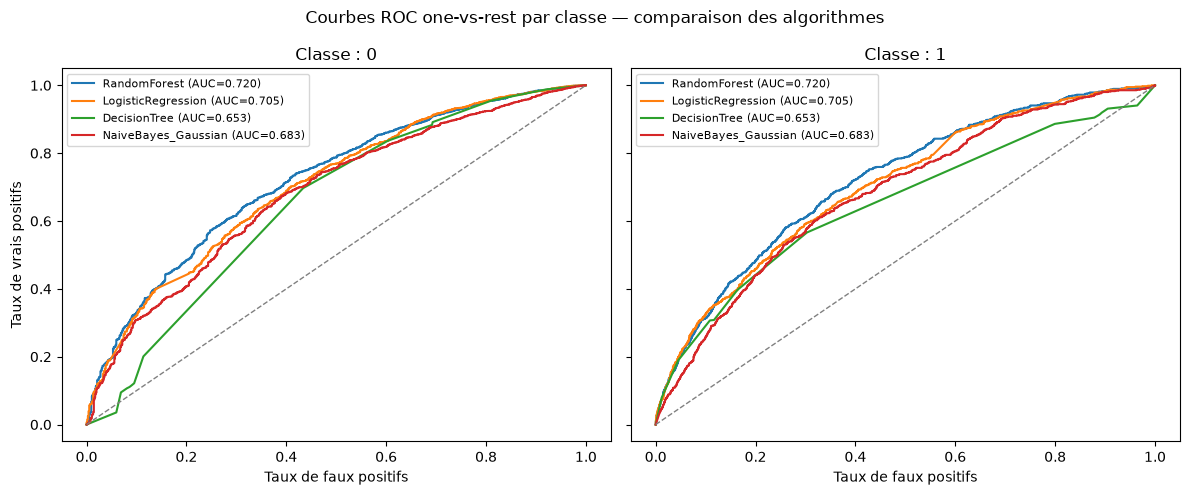

In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np

label_map_roc = dict(enumerate(modeles_entraines["RandomForest"].stages[len(encodage_stages)].labels))
classes_idx = sorted(label_map_roc.keys())


def extraire_probas_val(modele) -> pd.DataFrame:
    """label_idx réel + une colonne de probabilité prédite par classe, pour df_val."""
    preds = modele.transform(df_val).select("label_idx", "probability").toPandas()
    proba_array = np.vstack(preds["probability"].apply(lambda v: v.toArray()))
    for c in classes_idx:
        preds[f"proba_classe_{c}"] = proba_array[:, c]
    return preds


# Un seul transform() par algorithme (pas par classe) -- réutilisé ensuite pour les
# len(classes_idx) courbes de chaque algo.
probas_par_algo = {nom_algo: extraire_probas_val(modele) for nom_algo, modele in modeles_entraines.items()}

fig, axes = plt.subplots(1, len(classes_idx), figsize=(6 * len(classes_idx), 5), sharey=True)
if len(classes_idx) == 1:
    axes = [axes]

for c, ax in zip(classes_idx, axes):
    for nom_algo, preds_algo in probas_par_algo.items():
        y_true_binaire = (preds_algo["label_idx"] == c).astype(int)
        y_score = preds_algo[f"proba_classe_{c}"]
        fpr, tpr, _ = roc_curve(y_true_binaire, y_score)
        auc_score = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{nom_algo} (AUC={auc_score:.3f})")

    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
    ax.set_title(f"Classe : {label_map_roc[c]}")
    ax.set_xlabel("Taux de faux positifs")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Taux de vrais positifs")
plt.suptitle("Courbes ROC one-vs-rest par classe — comparaison des algorithmes")
plt.tight_layout()
plt.show()

## 10. Sélection automatique + refit sur 100% du train & sauvegarde

Le modèle livré n'est plus `RandomForest` figé en dur : on prend automatiquement le vainqueur de
`comparaison_finale` (F1 classe 1, section 9quater) parmi tous les candidats (MLlib + XGBoost +
LightGBM), puis on le refit sur `df_train_full` en entier (nettoyé Tomek Links, section 3) --
le split 80/20 (section 4) ne sert qu'à évaluer honnêtement, pas à priver le modèle final de 20%
des données. `poids_classe` est recalculé sur la population complète (section 5).

**Deux branches de sauvegarde** selon le vainqueur :
- **MLlib** : `Pipeline` complet (encodage + classifieur) refit et sauvegardé en `PipelineModel`
  à `MODEL_PATH`, comme en V1.1.
- **XGBoost/LightGBM** : pas de `PipelineModel` MLlib possible (modèle sklearn) -- on sauvegarde
  séparément l'encodeur Spark seul (`MODEL_PATH_encodeur`, refit sur 100%) et le modèle sklearn
  (`MODEL_PATH_sklearn.joblib`, mêmes hyperparamètres que ceux retenus par `RandomizedSearchCV`,
  refit sur 100% en pandas). La section 11 gère les deux cas à la lecture.


In [ ]:
import joblib

meilleur = comparaison_finale.sort_values("f1_classe1_val", ascending=False).iloc[0]
nom_meilleur_modele = meilleur["algo"]
print(f"Modele retenu : {nom_meilleur_modele}  (F1 classe 1 val = {meilleur['f1_classe1_val']:.4f})")

poids_par_classe_full = calculer_poids_classe(df_train_full)
df_train_full_pondere = df_train_full.join(poids_par_classe_full, on=COL_LABEL)

if nom_meilleur_modele in algos_config:
    TYPE_MODELE_FINAL = "mllib"
    pipeline_final = construire_pipeline_algo(algos_config[nom_meilleur_modele]["clf"])
    pipeline_model_final = pipeline_final.fit(df_train_full_pondere)
    pipeline_model_final.write().overwrite().save(MODEL_PATH)
    print(f"PipelineModel MLlib sauvegarde : {MODEL_PATH}")
else:
    TYPE_MODELE_FINAL = "sklearn"
    # Encodeur seul (memes stages que section 6, pas encore fittes), refit sur df_train_full --
    # pas sur df_fit (80%), pour livrer un encodeur appris sur toute la population.
    encodeur_full_pipeline = Pipeline(
        stages=construire_stages_encodage(COLS_CATEGORIELLES_BASSE_CARDINALITE, COL_HAUTE_CARDINALITE)
        + [label_indexer, assembler]
    )
    encodeur_final = encodeur_full_pipeline.fit(df_train_full)

    pdf_full = encodeur_final.transform(df_train_full).select("features", "label_idx").toPandas()
    X_full = pd.DataFrame(np.vstack(pdf_full["features"].apply(lambda v: v.toArray())), columns=feature_names_sklearn)
    # CORRECTIF (meme logique que section 9quater) : CODE_VILLE_idx n'est pas une quantite --
    # dtype "category" pour que SMOTENC/XGBoost/LightGBM le traitent comme la feature
    # categorielle qu'il est, pas comme un float continu.
    X_full[feature_names_sklearn[idx_code_ville]] = X_full[feature_names_sklearn[idx_code_ville]].astype("category")
    y_full = pdf_full["label_idx"].astype(int).values

    # SMOTENC ici aussi, meme logique qu'en 9quater (X_fit_smote) : on reequilibre la
    # classe minoritaire sur 100% du train avant le refit final, en respectant CODE_VILLE_idx.
    X_full_smote, y_full_smote = smote.fit_resample(X_full, y_full)
    X_full_smote[feature_names_sklearn[idx_code_ville]] = X_full_smote[feature_names_sklearn[idx_code_ville]].astype("category")

    modele_sklearn_final = xgb_model if nom_meilleur_modele == "XGBoost" else lgbm_model
    modele_sklearn_final.fit(X_full_smote, y_full_smote)  # memes hyperparametres, refit sur 100%

    # CORRECTIF : le seuil de decision retenu (section 9quater, tune sur df_val pour
    # maximiser le F1 classe 1) doit voyager avec le modele -- sans ca, le scoring
    # (section 11) retomberait sur le 0.5 par defaut de .predict(), qui a produit un F1
    # classe 1 quasi nul (0.03-0.05) avant ce correctif.
    seuil_final = seuil_xgb if nom_meilleur_modele == "XGBoost" else seuil_lgbm

    encodeur_final.write().overwrite().save(MODEL_PATH + "_encodeur")
    joblib.dump(modele_sklearn_final, MODEL_PATH + "_sklearn.joblib")
    joblib.dump({"seuil": seuil_final, "idx_code_ville": idx_code_ville, "feature_names": feature_names_sklearn},
                MODEL_PATH + "_meta.joblib")
    print(f"Encodeur Spark sauvegarde : {MODEL_PATH}_encodeur")
    print(f"Modele sklearn sauvegarde : {MODEL_PATH}_sklearn.joblib")
    print(f"Seuil retenu ({seuil_final:.2f}) + metadonnees sauvegardes : {MODEL_PATH}_meta.joblib")


26/07/15 13:53:03 WARN TaskSetManager: Stage 9389 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:03 WARN TaskSetManager: Stage 9392 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.



Poids par classe (total=93460, nb_classes=2) :


26/07/15 13:53:03 WARN TaskSetManager: Stage 9398 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.


+-----------------+------------------+
|label_eligibilite|      poids_classe|
+-----------------+------------------+
|                0| 0.521813897915201|
|                1|11.960583567954952|
+-----------------+------------------+



26/07/15 13:53:04 WARN TaskSetManager: Stage 9401 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:04 WARN TaskSetManager: Stage 9404 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:04 WARN TaskSetManager: Stage 9410 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:04 WARN TaskSetManager: Stage 9413 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:05 WARN TaskSetManager: Stage 9419 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:05 WARN TaskSetManager: Stage 9422 contains a task of very large size (2023 KiB). The maximum recommended task size is 1000 KiB.
26/07/15 13:53:05 WARN TaskSetManager: Stage 9428 contains a task of very large size (2023 KiB). The maximum recommended task size is 10

PipelineModel sauvegardé : ./models/scoring_pipeline


## 11. Scoring (`dataset_a_scorer`)

Chargement du modèle sauvegardé (branche MLlib ou sklearn selon `TYPE_MODELE_FINAL`, section 10)
et scoring de `dataset_a_scorer` -- aucun `.fit()` ici, tout ce qui a été appris vient de
`df_train_full`.

**CORRECTIF (déjà en V1.1)** : `IndexToString` (guide section 7.3) pour indice → nom de produit,
plutôt qu'un `F.udf(...)` manuel.


In [ ]:
if PATH_SCORER_IN is not None:
    df_scorer = spark.read.parquet(PATH_SCORER_IN)

    if TYPE_MODELE_FINAL == "mllib":
        pipeline_model_reload = PipelineModel.load(MODEL_PATH)
        predictions = pipeline_model_reload.transform(df_scorer)

        label_indexer_model = pipeline_model_reload.stages[len(encodage_stages)]
        converter = IndexToString(inputCol="prediction", outputCol="label_predit", labels=label_indexer_model.labels)
        predictions = converter.transform(predictions)

        cols_a_garder = [c for c in ["RADICAL", "CODE_VILLE"] if c in predictions.columns] + ["label_predit", "probability"]
        predictions.select(*cols_a_garder).show(20, truncate=False)
        predictions.write.mode("overwrite").parquet(PATH_PREDICTIONS_OUT)
    else:
        encodeur_reload = PipelineModel.load(MODEL_PATH + "_encodeur")
        modele_reload = joblib.load(MODEL_PATH + "_sklearn.joblib")
        # CORRECTIF : seuil + noms de colonnes/index CODE_VILLE_idx sauvegardes au refit
        # (section 10) -- sans ca, le scoring retomberait sur .predict() a 0.5 par defaut
        # (F1 classe 1 quasi nul avant ce correctif) et perdrait le dtype categoriel de
        # CODE_VILLE_idx que XGBoost/LightGBM attendent desormais.
        meta_reload = joblib.load(MODEL_PATH + "_meta.joblib")
        seuil_reload = meta_reload["seuil"]
        idx_code_ville_reload = meta_reload["idx_code_ville"]
        feature_names_reload = meta_reload["feature_names"]

        cols_id = [c for c in ["RADICAL", "CODE_VILLE"] if c in df_scorer.columns]
        pdf_scorer = encodeur_reload.transform(df_scorer).select(*cols_id, "features").toPandas()
        X_scorer = pd.DataFrame(np.vstack(pdf_scorer["features"].apply(lambda v: v.toArray())), columns=feature_names_reload)
        X_scorer[feature_names_reload[idx_code_ville_reload]] = X_scorer[feature_names_reload[idx_code_ville_reload]].astype("category")

        proba_scorer = modele_reload.predict_proba(X_scorer)[:, 1]
        pdf_scorer["label_predit"] = (proba_scorer >= seuil_reload).astype(int).astype(str)
        pdf_scorer["probability_classe1"] = proba_scorer
        pdf_scorer = pdf_scorer.drop(columns=["features"])

        print(pdf_scorer.head(20))
        spark.createDataFrame(pdf_scorer).write.mode("overwrite").parquet(PATH_PREDICTIONS_OUT)

    print(f"Predictions ecrites : {PATH_PREDICTIONS_OUT}")
else:
    print("PATH_SCORER_IN non defini (LOCAL_MODE=True, dataset_a_scorer pas encore teste en local) "
          "-- basculer LOCAL_MODE=False une fois pret pour le cluster complet.")


PATH_SCORER_IN non défini (LOCAL_MODE=True, dataset_a_scorer pas encore testé en local) -- basculer LOCAL_MODE=False une fois prêt pour le cluster complet.


## 12. Limites de cette V1.1 & prochaines étapes

Cette version corrige les deux lacunes signalées après la V1 (pas de pondération de classe, pas de
Tomek Links) et une affirmation fausse (voir ci-dessous). Points volontairement encore laissés de
côté, à traiter dans une V2 :

- **Correctif V1 → V1.1** : la V1 affirmait que `RandomForestClassifier` "ne supporte pas
  `weightCol` comme `LogisticRegression`". C'était faux et contredisait directement le guide
  (section 7.5, qui utilise `RandomForestClassifier(..., weightCol="poids_classe")`) — Spark 3.0+
  supporte `weightCol` sur `RandomForestClassifier`. Corrigé : la pondération est maintenant
  utilisée (section 5/6).
- **Pas de tuning d'hyperparamètres.** `numTrees=30, maxDepth=5` (section 6) sont des valeurs de
  départ raisonnables, pas optimisées -- alignées ici avec le code (avant correctif, ce texte
  mentionnait `100/8`, incohérent avec les valeurs réellement utilisées). À faire via `CrossValidator` + `ParamGridBuilder` sur `df_fit`
  (jamais sur `df_val`, qui doit rester un set d'évaluation propre — ou passer à un vrai
  train/val/test à 3 blocs si le tuning consomme le set de validation actuel).
- **Tomek Links non paramétré finement.** `sampling_strategy="auto"` nettoie toutes les classes
  majoritaires par défaut — à comparer avec une stratégie ciblée sur la classe la plus
  fréquente uniquement (`sampling_strategy={classe_majoritaire: ...}`) si le F1 des classes
  minoritaires ne s'améliore pas suffisamment.
- **Un seul algorithme essayé.** `RandomForestClassifier` choisi par défaut pour sa robustesse
  aux features non standardisées et à `CODE_VILLE_idx`, et son support natif de `weightCol`. À
  comparer avec `LogisticRegression` (`family="multinomial", weightCol=...`, nécessiterait un
  `StandardScaler` avant le `VectorAssembler`, cf. note EDA sur l'échelle des variables),
  `DecisionTreeClassifier` et `NaiveBayes` (ne supporte pas `weightCol` — guide section 7.9) :
  le guide donne la boucle de comparaison complète (section 7.9). **Mise à jour** : XGBoost et LightGBM ont été ajoutés en section 9quater (hors MLlib, pandas + `scale_pos_weight`/`class_weight="balanced"`). La métrique de sélection, partout dans le notebook (CrossValidator section 9bis, RandomizedSearchCV section 9quater, choix du modèle livré section 10), est désormais le **F1 de la classe 1** (`fMeasureByLabel`), pas le F1 pondéré -- qui restait élevé même pour un modèle ignorant la classe minoritaire.
- **Pas de cross-validation.** Un split 80/20 unique donne une estimation, pas une borne de
  confiance. `CrossValidator` (k=5 par ex.) donnerait une évaluation plus robuste avant la
  décision finale de modèle.
- **`CODE_VILLE_idx` reste un entier arbitraire** pour un modèle à base d'arbres, ce qui est
  acceptable (RandomForest peut apprendre des seuils sur un index sans supposer d'ordre
  linéaire), mais deviendrait un problème si un modèle linéaire est testé en V2 — prévoir un
  encodage par fréquence ou par cible (`target encoding`) à ce moment-là plutôt qu'un `OneHotEncoder`
  brut (273 colonnes).
- **`MODEL_PATH` codé pour un seul modèle**, pas de versionnement — à ajouter (timestamp ou
  numéro de version dans le chemin) avant tout déploiement réel.
- **Tomek Links + refit final (section 10)** : le fichier local de test n'a probablement pas de
  colonne `RADICAL` si `LOCAL_MODE=True` pointe vers un parquet déjà réduit — dans ce cas, la
  branche de repli en section 3 (`RADICAL_PRESENT = False`) reconstruit `df_train_full`
  uniquement à partir des colonnes numériques utilisées par Tomek, ce qui **supprimerait les
  colonnes catégorielles brutes nécessaires à l'encodage (section 6)**. À vérifier explicitement
  avant tout run complet : si `RADICAL` n'est pas dans le parquet nettoyé, l'ajouter en amont
  (Partie 1 EDA) plutôt que de contourner ici.